# Attempting to do the profile aggregation method on music voters set

In [1]:
import pandas as pd
import os, sys

# ---- 1️⃣ Find the directory that holds the `aggregation` package ----
start = os.path.abspath(os.getcwd())
if "__file__" in globals():                     
    start = os.path.abspath(os.path.dirname(__file__))

repo_root = start
while True:
    # Changed to search for your new folder
    if os.path.isdir(os.path.join(repo_root, "aggregation")):
        break                                   
    parent = os.path.dirname(repo_root)
    if parent == repo_root:                     
        raise RuntimeError("Could not find a directory containing 'aggregation'")
    repo_root = parent

# ---- 2️⃣ Insert it at the front of sys.path (if not already there) ----
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

# ---- 3️⃣ Framework and Library Imports ----
from splink import DuckDBAPI, Linker, SettingsCreator
from aggregation.engine import Aggregator

import splink.comparison_level_library as cll
import splink.comparison_library as cl

In [2]:
DF_PATH = os.path.join("..", "..", "public_datasets", "musicbrainz-20-A01.csv.dapo")

# DuckDB resource limits (same as in the original notebook)
MEM_LIMIT  = "24GB"
TEMP_DIR   = "./duckdb_spill_dir.tmp"

In [3]:
target_dir = os.path.dirname(DF_PATH)

# Import the files directly
df1 = pd.read_parquet(os.path.join(target_dir, "cleaned_music3.parq"))
df2 = pd.read_parquet(os.path.join(target_dir, "cleaned_music5.parq"))

In [16]:
df1

,TID,CID,CTID,SourceID,unique_id,number,title,length,artist,album,year,language,uai,length_ms,year_options,categorical_title,categorical_album,numerical_noisy,categorical_number
0,6,5,1,3,49425110MB-01,6.0,Try (acoustic),None,Neil Young,"2008-02-15: Le Grand Rex, Paris, France",None,English,uai_838,NaN,None,Try (acoustic),"2008-02-15: Le Grand Rex, Paris, France",NaN,6.0
1,21,3118,2,3,4763264MB-01,6.0,Cállate,4.367,Wisin & Yandel,Los vaqueros: el regreso: Deluxe Edition,'11,Spanish,uai_13,262020.0,"[1911, 2011]",Cállate,Los vaqueros: el regreso: Deluxe Edition,262020.0,6.0
2,25,5893,2,3,50116112MB-01,9.0,Fish Tail Blues,3.085,Jelly Roll Morton,The King & Mister Jelly Lord,'89,English,uai_604,185100.0,[1989],Fish Tail Blues,The King & Mister Jelly Lord,185100.0,9.0
3,39,519,3,3,5235450MB-01,13.0,Mu sõber tuul,4.567,Laine,Uus Laine,'00,Estonian,uai_5829,274020.0,"[1900, 2000]",Mu sõber tuul,Uus Laine,274020.0,13.0
4,44,25,1,3,23433710MB-01,2.0,Fried Bananas,12.3,Dexter Gordon,Live at the Amsterdam Paradiso,'94,English,uai_230,738000.0,[1994],Fried Bananas,Live at the Amsterdam Paradiso,738000.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3921,19366,9994,1,3,11546013MB-01,12.0,Steal Away,4.424,Dublin City Ramblers,Flight of Earls,None,English,uai_567,265440.0,None,Steal Away,Flight of Earls,265440.0,12.0
3922,19368,9995,1,3,14504822MB-01,4.0,I Am What I Am (live at Abbey Road),4.374,Mark Owen,Clementine,None,English,uai_5985,262440.0,None,I Am What I Am (live at Abbey Road),Clementine,262440.0,4.0
3923,19370,9996,1,3,70007517MB-01,9.0,Sukkana alas!,2.928,Popeda,Kans'an Popeda,'05,Finnish,uai_2780,175680.0,"[1905, 2005]",Sukkana alas!,Kans'an Popeda,175680.0,9.0
3924,19372,9998,1,3,37406511MB-01,5.0,The Pressure of Pitching Doves,1.85,Buddy Wakefield,Run on Anything,None,English,uai_5179,111000.0,None,The Pressure of Pitching Doves,Run on Anything,111000.0,5.0


In [4]:
import ast
import pandas as pd

import ast
import pandas as pd
import numpy as np

def process_music_data(df):
    # Combine columns, handling potential missing values gracefully
    df["categorical_title"] = df["title"]

    df["categorical_album"] = df["album"]

    df["numerical_noisy"] = df["length_ms"]

    df["categorical_number"] = df["number"]

    # Robust filter handling lists, arrays, strings, and missing values safely
    def safe_filter_years(x):
        # 1. Safely handle None, NaN, or empty values
        if x is None or (isinstance(x, (float, int)) and pd.isna(x)):
            return x
            
        # 2. Convert string representation of lists to real lists
        if isinstance(x, str):
            try:
                x = ast.literal_eval(x)
            except (ValueError, SyntaxError):
                return x
        
        # 3. Handle actual lists or numpy arrays
        if isinstance(x, (list, np.ndarray)):
            return [int(year) for year in x if int(year) <= 2026]
            
        return x

    df["year_options"] = df["year_options"].apply(safe_filter_years)

    # Return only the requested columns
    target_columns = [
        "uai",
        "artist",
        "categorical_title",
        "categorical_album",
        "categorical_number",
        "numerical_noisy",
        "language",
        "year_options",
    ]
    return df[target_columns].copy()



# Apply to your dataframes
df1_processed = process_music_data(df1)
df2_processed = process_music_data(df2)


In [18]:
df1_processed

,uai,artist,categorical_title,categorical_album,categorical_number,numerical_noisy,language,year_options
0,uai_838,Neil Young,Try (acoustic),"2008-02-15: Le Grand Rex, Paris, France",6.0,NaN,English,None
1,uai_13,Wisin & Yandel,Cállate,Los vaqueros: el regreso: Deluxe Edition,6.0,262020.0,Spanish,"[1911, 2011]"
2,uai_604,Jelly Roll Morton,Fish Tail Blues,The King & Mister Jelly Lord,9.0,185100.0,English,[1989]
3,uai_5829,Laine,Mu sõber tuul,Uus Laine,13.0,274020.0,Estonian,"[1900, 2000]"
4,uai_230,Dexter Gordon,Fried Bananas,Live at the Amsterdam Paradiso,2.0,738000.0,English,[1994]
...,...,...,...,...,...,...,...,...
3921,uai_567,Dublin City Ramblers,Steal Away,Flight of Earls,12.0,265440.0,English,None
3922,uai_5985,Mark Owen,I Am What I Am (live at Abbey Road),Clementine,4.0,262440.0,English,None
3923,uai_2780,Popeda,Sukkana alas!,Kans'an Popeda,9.0,175680.0,Finnish,"[1905, 2005]"
3924,uai_5179,Buddy Wakefield,The Pressure of Pitching Doves,Run on Anything,5.0,111000.0,English,None


In [6]:
df2_processed

,uai,artist,categorical_title,categorical_album,categorical_number,numerical_noisy,language,year_options
0,uai_4269,Kathy Troccoli,Your Grace,Comfort,10.0,NaN,English,[2005]
1,uai_1397,Ernie Stadler Jazz Quintet,Well You Needn't,First Down,2.0,321266.0,English,[2010]
2,uai_299,Wendy Saddington,Just Like Tom Thumb's Blues (live),"Blues Women Anthology, Volume 7",9.0,462000.0,English,[2007]
3,uai_4401,Λαυρέντης Μαχαιρίίτσας,Στα καμένα,"Συλλογή Δίφωνο, 22: Μουσικοί βιότοποι",4.0,195000.0,Greek,[1997]
4,uai_4117,Anathema,None,Alternative 4,6.0,188400.0,English,[1998]
...,...,...,...,...,...,...,...,...
3823,uai_517,"John Cale, Tony Conrad, Angus MacLise, La Mont...","Inside the Dream Syndicate, Volume I: Day of N...","Inside the Dream Syndicate, Volume I: Day of N...",1.0,1854000.0,English,[2000]
3824,uai_2335,Charbel Rouuhana,Wedding,fma Festival du Monde Arabe de Montréal 10ième...,4.0,334000.0,French,None
3825,uai_1870,Sonny Stitt & Barry Harris,"Just You, Just Me",The Complete Late Quartets,9.0,296000.0,English,[2010]
3826,uai_4087,Icos,Nightmare,Fragments of Sirens,5.0,NaN,English,None


### Continuing

In [7]:
# We want to process these via bucketting.
type_groups = ["numerical", "categorical", "set_union"]

col_groups = [
    ["numerical_noisy"], 
    ["categorical_title","categorical_album", "language", "categorical_number"],
    ["year_options"]
]

# Instantiate and run
agg = Aggregator(type_groups=type_groups, col_groups=col_groups, unique_id_col="artist")


In [8]:
agg.fit(df1_processed, df2_processed)

# 4️⃣ Transform both DataFrames independently
aggregated_df1 = agg.transform(df1_processed, dataset_label="music_catalog_df1")
aggregated_df2 = agg.transform(df2_processed, dataset_label="music_catalog_df2")

aggregated_df1 = aggregated_df1.drop(columns=['categorical_title_vector', 'categorical_album_vector', 'language', 'language_vector'])
aggregated_df2 = aggregated_df2.drop(columns=['categorical_title_vector', 'categorical_album_vector', 'language', 'language_vector'])

# Display the head of the first aggregated result
aggregated_df1.head()

,artist,categorical_title,categorical_album,categorical_number,year_options,numerical_noisy_mean,numerical_noisy_min,numerical_noisy_max,categorical_number_vector,source_dataset
0,$wingin' Utter$,[Almost Brave],[Live at the Fireside Bowl],[1.0],[1995],124560.0,124560.0,124560.0,"[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",music_catalog_df1
1,1.6 Band,[Throwing Rocks],[Broke Up],[11.0],[],169980.0,169980.0,169980.0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, ...",music_catalog_df1
2,1.968,[7],[[unknown]],[],[],0.0,0.0,0.0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",music_catalog_df1
3,12 Moons,[Thunderbolt],[Nimbus/ Thunderbolt],[4.0],"[1903, 2003]",517980.0,517980.0,517980.0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",music_catalog_df1
4,12 Step Rebels,[Curse of the Pentagram],[Go Go Graveyard Rockin'],[12.0],[],367380.0,367380.0,367380.0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",music_catalog_df1


In [9]:
aggregated_df2.head()

,artist,categorical_title,categorical_album,categorical_number,year_options,numerical_noisy_mean,numerical_noisy_min,numerical_noisy_max,categorical_number_vector,source_dataset
0,$wingin' Utter$,[Storybook Disease],[The Streets of San Francisco],[1.0],[2001],142893.0,142893.0,142893.0,"[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",music_catalog_df2
1,(Flight FSM School Music),[Hendrix Law (Interlude)],"[First in Flight, Last to Land]",[18.0],[2010],0.0,0.0,0.0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",music_catalog_df2
2,(ghost),[Vertical],[Departur],[10.0],[2013],270693.0,270693.0,270693.0,"[0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",music_catalog_df2
3,(lo:muêso),[...You Put Those Words in Our Mouth...],[(next:matêria)],[12.0],[2005],55990.0,55990.0,55990.0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",music_catalog_df2
4,132253,[9],[Johann Sebastian Bach],[16498361.0],[],0.0,0.0,0.0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",music_catalog_df2


In [22]:
### categorical_title actually probably has a lot more value, language possible? categorical_number seems somewhat valuable also
# in this case, i think a lot of the vectors are likely to be useless here.
# categorical_numerical is likely a fair usage of vectors - these are largely sparse
# for title, we have to adopt a better option: some sort of text-based set similarity function
# for language, we can attempt both vector concepts or the same text-based simialrity functions

In [23]:
def soft_jaccard_comparison(output_column_name: str, token_col_name: str) -> cl.CustomComparison:
    """
    Soft Jaccard (a.k.a. Generalized Jaccard / Fuzzy Jaccard with continuous scores).
    
    For each token in l, find its best match in r (max Jaro-Winkler). Sum these.
    For each token in r, find its best match in l (max Jaro-Winkler). Sum these.
    Divide by 2 * union_size for symmetric normalization.
    
    Properties:
    - |l|=1, |r|=1: score = jaro_winkler(a, b) ✅
    - |l|=n, |r|=m: smooth average of mutual best-matches, normalized by union
    - Range: [0, 1]
    """
    # Sum of best matches from l to r
    max_sims_l_sql = f"""
        list_aggregate(
            list_transform({token_col_name}_l, x -> list_max(list_transform({token_col_name}_r, y -> jaro_winkler_similarity(x, y)))),
            'sum'
        )
    """
    # Sum of best matches from r to l
    max_sims_r_sql = f"""
        list_aggregate(
            list_transform({token_col_name}_r, y -> list_max(list_transform({token_col_name}_l, x -> jaro_winkler_similarity(x, y)))),
            'sum'
        )
    """
    # Union of distinct tokens
    union_sql = f"len(list_distinct(list_concat({token_col_name}_l, {token_col_name}_r)))"
    
    # Symmetric soft Jaccard: average mutual best-match / union size
    score_formula = f"({max_sims_l_sql} + {max_sims_r_sql}) / (2.0 * {union_sql})"

    return cl.CustomComparison(
        output_column_name=output_column_name,
        comparison_levels=[
            {
                "sql_condition": f"{token_col_name}_l IS NULL OR {token_col_name}_r IS NULL OR len({token_col_name}_l) = 0 OR len({token_col_name}_r) = 0",
                "label_for_charts": "Null or Empty List",
                "is_null_level": True
            },
            {"sql_condition": f"{score_formula} >= 0.85", "label_for_charts": "High Soft Jaccard (>=0.85)"},
            {"sql_condition": f"{score_formula} >= 0.65", "label_for_charts": "Medium Soft Jaccard (>=0.65)"},
            {"sql_condition": f"{score_formula} >= 0.40", "label_for_charts": "Low Soft Jaccard (>=0.40)"},
            cll.ElseLevel()
        ]
    )


def monge_elkan_comparison(output_column_name: str, token_col_name: str) -> cl.CustomComparison:
    """
    Monge-Elkan Similarity (asymmetric: query -> reference).
    
    For each token in l, find its best match in r. Average these maximums.
    
    Properties:
    - |l|=1, |r|=1: score = jaro_winkler(a, b) ✅
    - |l|=n, |r|=m: (1/n) * Σᵢ maxⱼ jaro(lᵢ, rⱼ) — normalized sum of best matches per query token
    - Asymmetric: role of l vs r matters
    - Range: [0, 1]
    """
    max_similarities_array_sql = f"""
        list_transform(
            {token_col_name}_l,
            x -> list_max(list_transform({token_col_name}_r, y -> jaro_winkler_similarity(x, y)))
        )
    """
    monge_elkan_score_sql = f"list_aggregate({max_similarities_array_sql}, 'sum') / len({token_col_name}_l)"

    return cl.CustomComparison(
        output_column_name=output_column_name,
        comparison_levels=[
            {
                "sql_condition": f"{token_col_name}_l IS NULL OR {token_col_name}_r IS NULL OR len({token_col_name}_l) = 0 OR len({token_col_name}_r) = 0",
                "label_for_charts": "Null or Empty List",
                "is_null_level": True
            },
            {"sql_condition": f"{monge_elkan_score_sql} >= 0.85", "label_for_charts": "High Monge-Elkan (>=0.85)"},
            {"sql_condition": f"{monge_elkan_score_sql} >= 0.70", "label_for_charts": "Medium Monge-Elkan (>=0.70)"},
            {"sql_condition": f"{monge_elkan_score_sql} >= 0.55", "label_for_charts": "Low Monge-Elkan (>=0.55)"},
            cll.ElseLevel()
        ]
    )

In [24]:
def soft_dice_comparison(output_column_name: str, token_col_name: str) -> cl.CustomComparison:
    """
    Soft Dice Coefficient (Symmetric mutual best-matches divided by total slots).
    
    For each token in l, find its best match in r (max Jaro-Winkler). Sum these.
    For each token in r, find its best match in l (max Jaro-Winkler). Sum these.
    Divide by (len(l) + len(r)) for symmetric normalization.
    
    Properties:
    - |l|=1, |r|=1: score = jaro_winkler(a, b) ✅
    - Range: [0, 1]
    """
    # Sum of best matches from l to r
    max_sims_l_sql = f"""
        list_aggregate(
            list_transform({token_col_name}_l, x -> list_max(list_transform({token_col_name}_r, y -> jaro_winkler_similarity(x, y)))),
            'sum'
        )
    """
    # Sum of best matches from r to l
    max_sims_r_sql = f"""
        list_aggregate(
            list_transform({token_col_name}_r, y -> list_max(list_transform({token_col_name}_l, x -> jaro_winkler_similarity(x, y)))),
            'sum'
        )
    """
    
    # Total length of both sides combined
    total_len_sql = f"(len({token_col_name}_l) + len({token_col_name}_r))"
    
    # Soft Dice: sum of mutual best-matches divided by total length
    score_formula = f"({max_sims_l_sql} + {max_sims_r_sql}) / {total_len_sql}"

    return cl.CustomComparison(
        output_column_name=output_column_name,
        comparison_levels=[
            {
                "sql_condition": f"{token_col_name}_l IS NULL OR {token_col_name}_r IS NULL OR len({token_col_name}_l) = 0 OR len({token_col_name}_r) = 0",
                "label_for_charts": "Null or Empty List",
                "is_null_level": True
            },
            {"sql_condition": f"{score_formula} >= 0.85", "label_for_charts": "High Soft Dice (>=0.85)"},
            {"sql_condition": f"{score_formula} >= 0.65", "label_for_charts": "Medium Soft Dice (>=0.65)"},
            {"sql_condition": f"{score_formula} >= 0.40", "label_for_charts": "Low Soft Dice (>=0.40)"},
            cll.ElseLevel()
        ]
    )

def soft_simpson_comparison(output_column_name: str, token_col_name: str) -> cl.CustomComparison:
    """
    Soft Simpson Coefficient (Mutual best-matches normalized by the smaller catalog size).
    
    For each token in l, find its best match in r (max Jaro-Winkler). Sum these.
    For each token in r, find its best match in l (max Jaro-Winkler). Sum these.
    Divide the average mutual match by the minimum list length using LEAST().
    
    Properties:
    - |l|=1, |r|=1: score = jaro_winkler(a, b) ✅
    - Immune to size imbalances (excellent for partial vs full catalogs)
    - Range: [0, 1]
    """
    # Sum of best matches from l to r
    max_sims_l_sql = f"""
        list_aggregate(
            list_transform({token_col_name}_l, x -> list_max(list_transform({token_col_name}_r, y -> jaro_winkler_similarity(x, y)))),
            'sum'
        )
    """
    # Sum of best matches from r to l
    max_sims_r_sql = f"""
        list_aggregate(
            list_transform({token_col_name}_r, y -> list_max(list_transform({token_col_name}_l, x -> jaro_winkler_similarity(x, y)))),
            'sum'
        )
    """
    
    # Find the size of the smaller catalog using DuckDB's LEAST function
    min_len_sql = f"least(len({token_col_name}_l), len({token_col_name}_r))"
    
    # Soft Simpson: average mutual best-match divided by minimum size
    score_formula = f"({max_sims_l_sql} + {max_sims_r_sql}) / (2.0 * {min_len_sql})"

    return cl.CustomComparison(
        output_column_name=output_column_name,
        comparison_levels=[
            {
                "sql_condition": f"{token_col_name}_l IS NULL OR {token_col_name}_r IS NULL OR len({token_col_name}_l) = 0 OR len({token_col_name}_r) = 0",
                "label_for_charts": "Null or Empty List",
                "is_null_level": True
            },
            {"sql_condition": f"{score_formula} >= 0.85", "label_for_charts": "High Soft Simpson (>=0.85)"},
            {"sql_condition": f"{score_formula} >= 0.65", "label_for_charts": "Medium Soft Simpson (>=0.65)"},
            {"sql_condition": f"{score_formula} >= 0.40", "label_for_charts": "Low Soft Simpson (>=0.40)"},
            cll.ElseLevel()
        ]
    )


In [25]:
def jaccard_similarity_comparison(output_column_name: str, token_col_name: str) -> cl.CustomComparison:
    """
    Abstracted exact Jaccard similarity. Empty arrays go straight to Null Level.
    """
    intersect_sql = f"len(list_intersect({token_col_name}_l, {token_col_name}_r)) * 1.0"
    union_sql = f"NULLIF(len(list_distinct(list_concat({token_col_name}_l, {token_col_name}_r))), 0)"
    score_formula = f"({intersect_sql}) / {union_sql}"

    return cl.CustomComparison(
        output_column_name=output_column_name,
        comparison_levels=[
            # Custom Null Level: Catches database NULLs AND empty lists
            {
                "sql_condition": f"{token_col_name}_l IS NULL OR {token_col_name}_r IS NULL OR len({token_col_name}_l) = 0 OR len({token_col_name}_r) = 0",
                "label_for_charts": "Null or Empty List",
                "is_null_level": True
            },
            {"sql_condition": f"{score_formula} >= 0.8", "label_for_charts": "High Jaccard (>=0.8)"},
            {"sql_condition": f"{score_formula} >= 0.4", "label_for_charts": "Medium Jaccard (>=0.4)"},
            {"sql_condition": f"{score_formula} >= 0.1", "label_for_charts": "Low Jaccard (>=0.1)"},
            cll.ElseLevel()
        ]
    )


def mag_cosine_similarity_comparison(output_column_name: str, vector_col_name: str) -> cl.CustomComparison:
    """
    Abstracted Magnitude-Weighted Cosine Similarity. Zero-magnitude vectors go to Null Level.
    """
    dot_l_l = f"list_dot_product({vector_col_name}_l, {vector_col_name}_l)"
    dot_r_r = f"list_dot_product({vector_col_name}_r, {vector_col_name}_r)"
    dot_l_r = f"list_dot_product({vector_col_name}_l, {vector_col_name}_r)"
    
    norm_l = f"sqrt({dot_l_l})"
    norm_r = f"sqrt({dot_r_r})"

    score_calculation = f"""
        ({dot_l_r} / ({norm_l} * {norm_r})) 
        * 
        (CASE 
            WHEN {norm_l} <= {norm_r} THEN {norm_l} / {norm_r}
            ELSE {norm_r} / {norm_l}
        END)
    """

    return cl.CustomComparison(
        output_column_name=output_column_name,
        comparison_levels=[
            # Custom Null Level: Catches database NULLs AND flat/zero-magnitude vectors
            {
                "sql_condition": f"{vector_col_name}_l IS NULL OR {vector_col_name}_r IS NULL OR COALESCE({dot_l_l}, 0) = 0 OR COALESCE({dot_r_r}, 0) = 0",
                "label_for_charts": "Null or Empty Vector",
                "is_null_level": True
            },
            {"sql_condition": f"({score_calculation}) >= 0.90", "label_for_charts": "High Mag-Cosine (>=0.90)"},
            {"sql_condition": f"({score_calculation}) >= 0.60", "label_for_charts": "Medium Mag-Cosine (>=0.60)"},
            {"sql_condition": f"({score_calculation}) >= 0.10", "label_for_charts": "Low Mag-Cosine (>=0.10)"},
            cll.ElseLevel()
        ]
    )


def simpson_similarity_comparison(output_column_name: str, token_col_name: str) -> cl.CustomComparison:
    intersect_sql = f"len(list_intersect({token_col_name}_l, {token_col_name}_r)) * 1.0"
    min_size_sql = f"NULLIF(least(len({token_col_name}_l), len({token_col_name}_r)), 0)"
    score_formula = f"({intersect_sql}) / {min_size_sql}"

    return cl.CustomComparison(
        output_column_name=output_column_name,
        comparison_levels=[
            {
                "sql_condition": f"{token_col_name}_l IS NULL OR {token_col_name}_r IS NULL OR len({token_col_name}_l) = 0 OR len({token_col_name}_r) = 0",
                "label_for_charts": "Null or Empty List",
                "is_null_level": True
            },
            {"sql_condition": f"{score_formula} >= 0.8", "label_for_charts": "High Simpson (>=0.8)"},
            {"sql_condition": f"{score_formula} >= 0.5", "label_for_charts": "Medium Simpson (>=0.5)"},
            {"sql_condition": f"{score_formula} >= 0.2", "label_for_charts": "Low Simpson (>=0.2)"},
            {
                "sql_condition": f"{score_formula} < 0.2",
                "label_for_charts": "No Simpson Overlap (<0.2)",
            }
        ]
    )

In [26]:
def numerical_overlap_similarity_comparison(output_column_name: str, base_col_name: str) -> cl.CustomComparison:
    """
    Abstracted Numerical Distribution Overlap Coefficient comparison.
    Uses the min and max column variants produced by the Aggregator.
    """
    max_l = f"{base_col_name}_max_l"
    max_r = f"{base_col_name}_max_r"
    min_l = f"{base_col_name}_min_l"
    min_r = f"{base_col_name}_min_r"

    # Core mathematical formula capturing range overlap vs full span bounding boxes
    score_formula = f"""
        CASE
            WHEN (least({max_l}, {max_r}) - greatest({min_l}, {min_r})) <= 0 THEN 0.0
            ELSE
                (least({max_l}, {max_r}) - greatest({min_l}, {min_r})) * 1.0 /
                NULLIF((greatest({max_l}, {max_r}) - least({min_l}, {min_r})), 0)
        END
    """

    return cl.CustomComparison(
        output_column_name=output_column_name,
        comparison_levels=[
            # Uses the base column name structure to catch initialization null boundaries safely
            cll.NullLevel(f"{base_col_name}_mean"),
            {"sql_condition": f"{score_formula} >= 0.8", "label_for_charts": "High Overlap (>=0.8)"},
            {"sql_condition": f"{score_formula} >= 0.5", "label_for_charts": "Medium Overlap (>=0.5)"},
            {"sql_condition": f"{score_formula} >= 0.2", "label_for_charts": "Low Overlap (>=0.2)"},
            cll.ElseLevel()
        ]
    )

In [27]:
def year_overlap_comparison(output_column_name: str, token_col_name: str) -> cl.CustomComparison:
    """
    Normalized Year Overlap comparison using the Simpson Overlap Coefficient.
    
    Measures what percentage of the smaller year list overlaps with the larger list.
    Immune to scenarios where one dataset has a deep history and the other has few years.
    """
    # Size of the intersection
    intersect_sql = f"len(list_intersect({token_col_name}_l, {token_col_name}_r))"
    
    # Size of the smaller list of the two sides
    min_len_sql = f"least(len({token_col_name}_l), len({token_col_name}_r))"
    
    # Simpson Overlap Ratio formula
    score_formula = f"({intersect_sql} * 1.0) / {min_len_sql}"
    
    return cl.CustomComparison(
        output_column_name=output_column_name,
        comparison_levels=[
            {
                "sql_condition": f"{token_col_name}_l IS NULL OR {token_col_name}_r IS NULL OR len({token_col_name}_l) = 0 OR len({token_col_name}_r) = 0",
                "label_for_charts": "No Year Data",
                "is_null_level": True
            },
            {
                "sql_condition": f"{score_formula} >= 0.90",
                "label_for_charts": "High Year Overlap (>=90% of smaller list matches)",
            },
            {
                "sql_condition": f"{score_formula} >= 0.50",
                "label_for_charts": "Medium Year Overlap (>=50% of smaller list matches)",
            },
            {
                "sql_condition": f"{score_formula} > 0.00",
                "label_for_charts": "Partial Year Overlap (>0% matches)",
            },
            cll.ElseLevel()
        ]
    )


In [28]:
blocking_rules = [
    # 2. At least one intersecting categorical_number
    """
    len(list_intersect(l.categorical_number, r.categorical_number)) >= 1
    """,
]


settings = {
    "link_type": "link_only",
    "unique_id_column_name": "artist",
    "probability_two_random_records_match": 0.001,
    "retain_matching_columns": True,
    "retain_intermediate_calculation_columns": True,
    "blocking_rules_to_generate_predictions": blocking_rules,
    "comparisons": [
        # 1. Categorical Title: Evaluated exclusively by text-based array strategies
        # jaccard_similarity_comparison(
        #     output_column_name="title_jaccard", 
        #     token_col_name="categorical_title"
        # ),
        soft_dice_comparison(
            output_column_name="title_soft_dice", 
            token_col_name="categorical_title"
        ),
        soft_simpson_comparison(
            output_column_name="title_soft_simpson", 
            token_col_name="categorical_title"
        ), 

        # Language: Evaluated via BOTH text-based token arrays and frequency vectors # but lowk useless
        # jaccard_similarity_comparison(
        #     output_column_name="language_jaccard", 
        #     token_col_name="language"
        # ),
        # mag_cosine_similarity_comparison(
        #     output_column_name="language_cosine", 
        #     vector_col_name="language_vector"
        # ),

        # Year options: Evaluate via jaccard - simpson wasn't stable
        year_overlap_comparison(
            output_column_name="year_overlap", 
            token_col_name="year_options"
        ),

        # Categorical_number: Evaluated strictly by frequency vectors
        simpson_similarity_comparison(
            output_column_name="cat_number_simpson", 
            token_col_name="categorical_number"
        ),

        # Numerical_noisy: Evaluated via min/max distribution range overlaps
        numerical_overlap_similarity_comparison(
            output_column_name="noisy_distribution_overlap", 
            base_col_name="numerical_noisy"
        )
    ]
}

In [29]:
import duckdb

con = duckdb.connect(database="splink_temp_workspace_music.duckdb")

# 2. Hard-cap the RAM allocation (e.g., limit it to 4 Gigabytes)
con.execute("SET memory_limit = '24GB';")

# 3. Explicitly define where intermediate results should spill on your hard drive
con.execute("SET temp_directory = './duckdb_spill_dir.tmp';")

db_api = DuckDBAPI(
    connection = con
)


In [30]:
from splink import Linker

linker = Linker([aggregated_df1, aggregated_df2], settings, db_api=db_api)

In [31]:
linker.training.estimate_u_using_random_sampling(max_pairs=1e8)

----- Estimating u probabilities using random sampling -----

Estimated u probabilities using random sampling

Your model is not yet fully trained. Missing estimates for:
    - title_soft_dice (no m values are trained).
    - title_soft_simpson (no m values are trained).
    - year_overlap (no m values are trained).
    - cat_number_simpson (no m values are trained).
    - noisy_distribution_overlap (no m values are trained).


In [32]:
# # ======================================================================
# # 1️⃣ Language Vector Cosine Rules (Binned)
# # ======================================================================
# train_lang_cosine_high = """
#     (list_dot_product(l.language_vector, l.language_vector) * list_dot_product(r.language_vector, r.language_vector) > 0) AND
#     (list_dot_product(l.language_vector, r.language_vector) /
#     (sqrt(list_dot_product(l.language_vector, l.language_vector)) *
#      sqrt(list_dot_product(r.language_vector, r.language_vector)))) >= 0.8
# """

# train_lang_cosine_med = """
#     (list_dot_product(l.language_vector, l.language_vector) * list_dot_product(r.language_vector, r.language_vector) > 0) AND
#     (list_dot_product(l.language_vector, r.language_vector) /
#     (sqrt(list_dot_product(l.language_vector, l.language_vector)) *
#      sqrt(list_dot_product(r.language_vector, r.language_vector)))) >= 0.5
# """

# ======================================================================
# 2️⃣ Categorical Number Vector Cosine Rules (Binned)
# ======================================================================
# train_cat_num_cosine_high = """
#     (list_dot_product(l.categorical_number_vector, l.categorical_number_vector) * list_dot_product(r.categorical_number_vector, r.categorical_number_vector) > 0) AND
#     (list_dot_product(l.categorical_number_vector, r.categorical_number_vector) /
#     (sqrt(list_dot_product(l.categorical_number_vector, l.categorical_number_vector)) *
#      sqrt(list_dot_product(r.categorical_number_vector, r.categorical_number_vector)))) >= 0.8
# """

# train_cat_num_cosine_med = """
#     (list_dot_product(l.categorical_number_vector, l.categorical_number_vector) * list_dot_product(r.categorical_number_vector, r.categorical_number_vector) > 0) AND
#     (list_dot_product(l.categorical_number_vector, r.categorical_number_vector) /
#     (sqrt(list_dot_product(l.categorical_number_vector, l.categorical_number_vector)) *
#      sqrt(list_dot_product(r.categorical_number_vector, r.categorical_number_vector)))) >= 0.5
# """

# ======================================================================
# 3️⃣ Numerical Noisy Overlap Rule (Loose threshold for broad matching)
# ======================================================================
train_noisy_overlap = """
    CASE
        WHEN (least(l.numerical_noisy_max, r.numerical_noisy_max) -
              greatest(l.numerical_noisy_min, r.numerical_noisy_min)) <= 0 THEN 0.0
        ELSE
            (least(l.numerical_noisy_max, r.numerical_noisy_max) -
             greatest(l.numerical_noisy_min, r.numerical_noisy_min)) * 1.0 /
            NULLIF((greatest(l.numerical_noisy_max, r.numerical_noisy_max) -
                    least(l.numerical_noisy_min, r.numerical_noisy_min)), 0)
    END >= 0.2
"""

# ======================================================================
# 4️⃣ Token Overlap Safety Net (Catches partial text matches)
# ======================================================================
train_token_intersection = """
    len(list_intersect(l.year_options, r.year_options)) >= 1
"""

### for exact overlap

train_cat_number_exact_overlap = """
    len(list_intersect(l.categorical_number, r.categorical_number)) >= 1
"""



# ADD to cell aa1a7ee2 (before training_blocking_rules):

train_title_soft_jaccard = """
    CASE
        WHEN l.categorical_title IS NULL OR r.categorical_title IS NULL 
             OR len(l.categorical_title) = 0 OR len(r.categorical_title) = 0 THEN 0.0
        ELSE
            (
                list_aggregate(
                    list_transform(l.categorical_title, x -> list_max(list_transform(r.categorical_title, y -> jaro_winkler_similarity(x, y)))),
                    'sum'
                ) + 
                list_aggregate(
                    list_transform(r.categorical_title, y -> list_max(list_transform(l.categorical_title, x -> jaro_winkler_similarity(x, y)))),
                    'sum'
                )
            ) / (
                2.0 * NULLIF(len(list_distinct(list_concat(l.categorical_title, r.categorical_title))), 0)
            )
    END >= 0.65
"""

# Then UPDATE training_blocking_rules:



# ======================================================================
# 5️⃣ Compile & Execute EM
# ======================================================================
training_blocking_rules = [
    train_cat_number_exact_overlap,
    train_noisy_overlap,
    train_token_intersection,
    train_title_soft_jaccard      # NEW: gives EM signal for title comparisons
]

# Estimate weights across all rules to populate model parameters
for rule in training_blocking_rules:
    linker.training.estimate_parameters_using_expectation_maximisation(rule)



----- Starting EM training session -----

Estimating the m probabilities of the model by blocking on:

    len(list_intersect(l.categorical_number, r.categorical_number)) >= 1


Parameter estimates will be made for the following comparison(s):
    - title_soft_dice
    - title_soft_simpson
    - year_overlap
    - noisy_distribution_overlap

Parameter estimates cannot be made for the following comparison(s) since they are used in the blocking rules: 
    - cat_number_simpson

Iteration 1: Largest change in params was -0.922 in the m_probability of noisy_distribution_overlap, level `High Overlap (>=0.8)`
Iteration 2: Largest change in params was -0.385 in the m_probability of title_soft_dice, level `High Soft Dice (>=0.85)`
Iteration 3: Largest change in params was 0.308 in the m_probability of title_soft_dice, level `Low Soft Dice (>=0.40)`
Iteration 4: Largest change in params was -0.0877 in the m_probability of title_soft_dice, level `High Soft Dice (>=0.85)`
Iteration 5: Largest ch

In [34]:
linker.visualisations.match_weights_chart()

alt.VConcatChart(...)

In [35]:
df_predict = linker.inference.predict()
pd_predict = df_predict.as_pandas_dataframe()

Blocking time: 3.23 seconds
Predict time: 3.12 seconds


In [36]:
pd_predict

,match_weight,match_probability,source_dataset_l,source_dataset_r,artist_l,artist_r,categorical_title_l,categorical_title_r,gamma_title_soft_dice,bf_title_soft_dice,...,bf_cat_number_simpson,numerical_noisy_mean_l,numerical_noisy_mean_r,numerical_noisy_min_l,numerical_noisy_min_r,numerical_noisy_max_l,numerical_noisy_max_r,gamma_noisy_distribution_overlap,bf_noisy_distribution_overlap,match_key
0,-8.616804,0.002541,music_catalog_df1,music_catalog_df2,Ryan Adams & The Cardnals,Van Morrison,[Magick],"[I Forgot That Love Existed, Take It Where You...",1,1.305867,...,3.297829,0.0,391586.5,0.0,260173.0,0.0,523000.0,0,0.985202,0
1,-5.644029,0.019606,music_catalog_df1,music_catalog_df2,Ryan Montbleau Band,Van Morrison,[Lonesome Serenade],"[I Forgot That Love Existed, Take It Where You...",1,1.305867,...,3.297829,282000.0,391586.5,282000.0,260173.0,282000.0,523000.0,0,0.985202,0
2,-5.704572,0.018815,music_catalog_df1,music_catalog_df2,Sade,Van Morrison,"[Tar Baby, When Am I Going to Make a Living]","[I Forgot That Love Existed, Take It Where You...",1,1.305867,...,28.153475,238020.0,391586.5,238020.0,260173.0,238020.0,523000.0,0,0.985202,0
3,-16.005816,0.000015,music_catalog_df1,music_catalog_df2,Sagar,Van Morrison,[Enemigo],"[I Forgot That Love Existed, Take It Where You...",0,0.007791,...,3.297829,274020.0,391586.5,274020.0,260173.0,274020.0,523000.0,0,0.985202,0
4,-8.798296,0.002241,music_catalog_df1,music_catalog_df2,Samhain,Van Morrison,[Macabre],"[I Forgot That Love Existed, Take It Where You...",1,1.305867,...,3.297829,130980.0,391586.5,130980.0,260173.0,130980.0,523000.0,0,0.985202,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
773171,-2.368813,0.162202,music_catalog_df1,music_catalog_df2,Louis Armstrong,Mendoza Dance Parti,"[Back O'Town Blues, Public Melody Number One, ...","[Hip Steps (live version), Stranded Duck]",1,1.305867,...,28.153475,186405.0,350266.5,139980.0,316933.0,218820.0,383600.0,0,0.985202,0
773172,-5.462537,0.022175,music_catalog_df1,music_catalog_df2,Lovett Sisters,Mendoza Dance Parti,[I Don't Want to Set the World on Fire],"[Hip Steps (live version), Stranded Duck]",1,1.305867,...,3.297829,158520.0,350266.5,158520.0,316933.0,158520.0,383600.0,0,0.985202,0
773173,-5.462537,0.022175,music_catalog_df1,music_catalog_df2,Luciano Pavarotti,Mendoza Dance Parti,[Brindisi],"[Hip Steps (live version), Stranded Duck]",1,1.305867,...,3.297829,207420.0,350266.5,207420.0,316933.0,207420.0,383600.0,0,0.985202,0
773174,-5.462537,0.022175,music_catalog_df1,music_catalog_df2,Lucybell,Mendoza Dance Parti,[Si no sé abrir mis manos],"[Hip Steps (live version), Stranded Duck]",1,1.305867,...,3.297829,240660.0,350266.5,240660.0,316933.0,240660.0,383600.0,0,0.985202,0


In [37]:
pd_predict.sort_values(by="match_probability", ascending=False).head(20)

,match_weight,match_probability,source_dataset_l,source_dataset_r,artist_l,artist_r,categorical_title_l,categorical_title_r,gamma_title_soft_dice,bf_title_soft_dice,...,bf_cat_number_simpson,numerical_noisy_mean_l,numerical_noisy_mean_r,numerical_noisy_min_l,numerical_noisy_min_r,numerical_noisy_max_l,numerical_noisy_max_r,gamma_noisy_distribution_overlap,bf_noisy_distribution_overlap,match_key
670473,16.827166,0.999991,music_catalog_df1,music_catalog_df2,Georg Friedrich Händel,Georg Friedrich Händel,[Opus 6 No. 12 in B minor (HWV 330) - I. Largo...,"[Act 2, Scene III: Recitativo - Voi quel folgi...",2,5.193989,...,487.39839,103240.000000,114602.400000,22680.0,11000.0,169380.0,250533.0,2,29.826290,0
9577,16.827166,0.999991,music_catalog_df1,music_catalog_df2,Wolfgang Amadeus Mozart,Wolfgang Amadeus Mozart,"[Requiem in D minor, K. 626 (Levin completion)...","[Die Zauberflöte, K. 620:Act I. ""Rüste dich mi...",2,5.193989,...,487.39839,291853.846154,411436.416667,85020.0,88800.0,584160.0,738026.0,2,29.826290,0
260559,16.143267,0.999986,music_catalog_df1,music_catalog_df2,Frédéric Chopin,Dexter Gordon,"[Nocturne No. 9 B-Dur, Op. 32 No. 1: Andante s...","[Three O'Clock in the Morning, Baby, Let's Be ...",1,1.305867,...,487.39839,318694.285714,416977.666667,57960.0,170000.0,850200.0,738000.0,2,29.826290,0
635792,16.143267,0.999986,music_catalog_df1,music_catalog_df2,Wolfgang Amadeus Mozart,Johann Sebastian Bach,"[Requiem in D minor, K. 626 (Levin completion)...","['Fughetta super' Gelobet seist du, Jesu Chris...",1,1.305867,...,487.39839,291853.846154,236483.478261,85020.0,45960.0,584160.0,681000.0,2,29.826290,0
645035,16.143267,0.999986,music_catalog_df1,music_catalog_df2,[unknown],Frank Zappa,"[Live-A-Humble, Oh Come All Ye Faithful Rock, ...","[Let Me Take You to the Beach, Bobby Brown, Th...",1,1.305867,...,487.39839,172920.000000,192489.750000,28980.0,55000.0,461340.0,380466.0,2,29.826290,0
260698,16.143267,0.999986,music_catalog_df1,music_catalog_df2,Ludwig van Beethoven,Dexter Gordon,"[Symphonie No. 6 en fa majeur, Op. 68 ""Pastora...","[Three O'Clock in the Morning, Baby, Let's Be ...",1,1.305867,...,487.39839,326080.000000,416977.666667,42000.0,170000.0,881760.0,738000.0,2,29.826290,0
635664,16.143267,0.999986,music_catalog_df1,music_catalog_df2,Wolfgang Amadeus Mozart,Frédéric Chopin,"[Requiem in D minor, K. 626 (Levin completion)...","[Three Nocturnes, Op. 9 No. 3 in B major, Sona...",1,1.305867,...,487.39839,291853.846154,347242.400000,85020.0,57973.0,584160.0,850173.0,2,29.826290,0
453572,16.143267,0.999986,music_catalog_df1,music_catalog_df2,Antonio Vivaldi,[unknown],"[Concerto grosso in F major, op.3/7, RV 567: I...","[Alecrim, Interlude, Indian Gold, Bewitched, B...",1,1.305867,...,487.39839,167400.000000,136288.125000,106380.0,20200.0,286020.0,364000.0,2,29.826290,0
716505,16.143267,0.999986,music_catalog_df1,music_catalog_df2,Frédéric Chopin,Johannes Brahms,"[Nocturne No. 9 B-Dur, Op. 32 No. 1: Andante s...","[Concerto for Violin and Cello in A minor, Op....",1,1.305867,...,487.39839,318694.285714,535297.666667,57960.0,204000.0,850200.0,1040000.0,2,29.826290,0
715978,16.143267,0.999986,music_catalog_df1,music_catalog_df2,Ludwig van Beethoven,Johann Sebastian Bach,"[Symphonie No. 6 en fa majeur, Op. 68 ""Pastora...","['Fughetta super' Gelobet seist du, Jesu Chris...",1,1.305867,...,487.39839,326080.000000,236483.478261,42000.0,45960.0,881760.0,681000.0,2,29.826290,0


In [38]:
# Extract the first row's values
titles_left = pd_predict.sort_values(by="match_probability", ascending=False).iloc[0]["categorical_title_l"]
titles_right = pd_predict.sort_values(by="match_probability", ascending=False).iloc[0]["categorical_title_r"]

print("--- Categorical Title Left (Full List) ---")
print(titles_left)

print("\n--- Categorical Title Right (Full List) ---")
print(titles_right)


--- Categorical Title Left (Full List) ---
['Opus 6 No. 12 in B minor (HWV 330) - I. Largo'
 'Soli & Chorus: Since by man'
 'Israel in Egypt: Part I, Exodus: 6. He spake the word (chorus)'
 'Messiah, HWV 56: Part III: L: Duet "O death, where is thy sting?" (alto, tenor)'
 'Deidamia: Atto II. Sinfonia' 'No.'
 'Belsazar: Act III. Recitativo "Suche nun eilig" (Cyrus)']

--- Categorical Title Right (Full List) ---
['Act 2, Scene III: Recitativo - Voi quel folgio lasciate (Serse/Atalanta)'
 'Pifa / Pifa' 'Sonata in F ,HWV 369, Allegro'
 'Belsazar: Act III. Recitativo "Suche nun eilig" (Cyrus)'
 'Air (from the Water Music)'
 'Opus 6 No. 12 in B minor (HWV 330) - I. Largo']


In [39]:
import numpy as np
import pandas as pd

# Calculate total true positive pairs (P) accounting for any duplicate IDs
total_p = pd.merge(
    aggregated_df1[["artist"]], aggregated_df2[["artist"]], on="artist"
).shape[0]

# Total possible pairs in a Cartesian product
total_cartesian_pairs = len(aggregated_df1) * len(aggregated_df2)
total_n = total_cartesian_pairs - total_p

print(f"Total True Matches (P): {total_p:,}")
print(f"Total True Non-Matches (N): {total_n:,}")


Total True Matches (P): 1,053
Total True Non-Matches (N): 12,699,362


In [40]:
# Create a column tracking if the prediction is an actual ground-truth match
pd_predict["is_true_match"] = (
    pd_predict["artist_l"] == pd_predict["artist_r"]
)

# Generate 30 threshold bins
thresholds = np.linspace(0.0, 1.0, 30)
metrics_log = []

for t in thresholds:
    # Filter predictions that meet or exceed the current threshold
    predicted_positives = pd_predict[pd_predict["match_probability"] >= t]

    # Calculate TP and FP from the predicted subset
    tp = predicted_positives["is_true_match"].sum()
    fp = len(predicted_positives) - tp

    # Calculate FN and TN using our global totals
    fn = total_p - tp
    tn = total_n - fp

    # Compute standard evaluation metrics
    precision = tp / (tp + fp) if (tp + fp) > 0 else 1.0
    recall = tp / total_p if total_p > 0 else 0.0
    f1 = (
        (2 * precision * recall) / (precision + recall)
        if (precision + recall) > 0
        else 0.0
    )
    accuracy = (tp + tn) / total_cartesian_pairs

    metrics_log.append(
        {
            "threshold": round(t, 4),
            "tp": tp,
            "fp": fp,
            "fn": fn,
            "tn": tn,
            "precision": round(precision, 4),
            "recall": round(recall, 4),
            "f1_score": round(f1, 4),
            "accuracy": round(accuracy, 4),
        }
    )

# Convert to DataFrame for easy viewing
df_threshold_curve = pd.DataFrame(metrics_log)
df_threshold_curve


,threshold,tp,fp,fn,tn,precision,recall,f1_score,accuracy
0,0.0000,861,772315,192,11927047,0.0011,0.8177,0.0022,0.9392
1,0.0345,840,61250,213,12638112,0.0135,0.7977,0.0266,0.9952
2,0.0690,840,12717,213,12686645,0.0620,0.7977,0.1150,0.9990
3,0.1034,835,9987,218,12689375,0.0772,0.7930,0.1406,0.9992
4,0.1379,834,6608,219,12692754,0.1121,0.7920,0.1964,0.9995
5,0.1724,824,5564,229,12693798,0.1290,0.7825,0.2215,0.9995
6,0.2069,801,5513,252,12693849,0.1269,0.7607,0.2175,0.9995
7,0.2414,801,4802,252,12694560,0.1430,0.7607,0.2407,0.9996
8,0.2759,801,4631,252,12694731,0.1475,0.7607,0.2470,0.9996
9,0.3103,801,4035,252,12695327,0.1656,0.7607,0.2720,0.9997


In [41]:
best_row = df_threshold_curve.loc[df_threshold_curve["f1_score"].idxmax()]
print(
    f"Optimal Threshold: {best_row['threshold']} with an F1-Score of {best_row['f1_score']}"
)


Optimal Threshold: 0.6552 with an F1-Score of 0.4112


ValueError: 'alpha' is not a valid value for ls; supported values are '-', '--', '-.', ':', 'None', ' ', '', 'solid', 'dashed', 'dashdot', 'dotted'

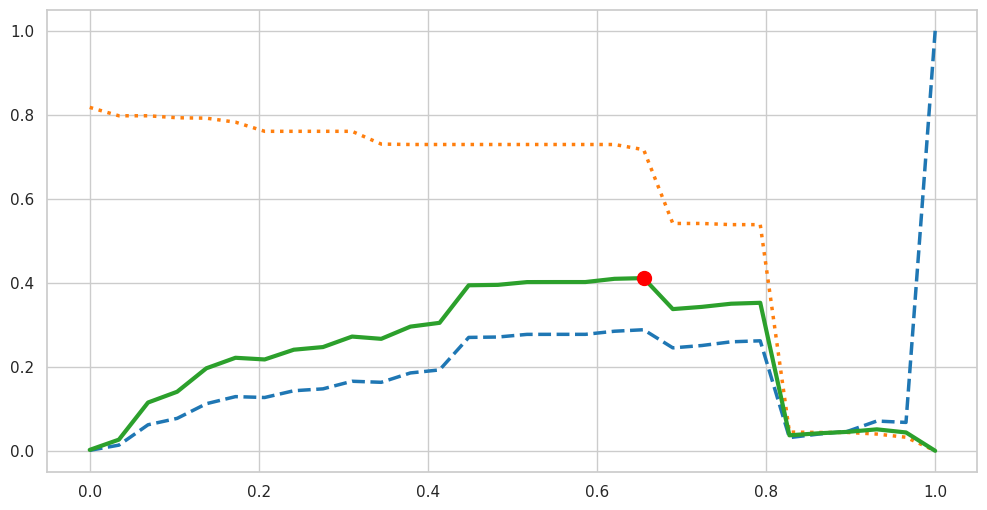

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set clean styling for the plot
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# Plot Precision, Recall, and F1 lines
plt.plot(df_threshold_curve["threshold"], df_threshold_curve["precision"], label="Precision", color="#1f77b4", linewidth=2.5, linestyle="--")
plt.plot(df_threshold_curve["threshold"], df_threshold_curve["recall"], label="Recall (Sensitivity)", color="#ff7f0e", linewidth=2.5, linestyle=":")
plt.plot(df_threshold_curve["threshold"], df_threshold_curve["f1_score"], label="F1-Score", color="#2ca02c", linewidth=3)

# Highlight the optimal F1 threshold
best_f1 = best_row["f1_score"]
best_thresh = best_row["threshold"]
plt.scatter(best_thresh, best_f1, color="red", s=100, zorder=5, label=f"Max F1 ({best_f1:.4f} @ {best_thresh:.2f})")
plt.axvline(x=best_thresh, color="red", linestyle="alpha", alpha=0.4, linewidth=1.5)

# Formatting text and layout
plt.title("Evaluation Metrics Across Probability Thresholds", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Match Probability Cutoff Threshold", fontsize=12)
plt.ylabel("Metric Score (0.0 to 1.0)", fontsize=12)
plt.xlim(0.0, 1.0)
plt.ylim(0.0, 1.05)
plt.xticks(np.arange(0.0, 1.1, 0.1))
plt.yticks(np.arange(0.0, 1.1, 0.1))
plt.legend(loc="lower left", frameon=True, fontsize=11)
plt.tight_layout()

# Render the final chart
plt.show()
